<a href="https://colab.research.google.com/github/dhruveesalian/UCF-Crime-Abnormal-Behavior-Detection/blob/main/UCF_Crime_ResNet18_Image_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision pillow ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

print("✅ ResNet18 model created")

Device: cuda
✅ ResNet18 model created


In [3]:
from google.colab import files

uploaded = files.upload()

Saving robbing.jpg to robbing.jpg


In [7]:
checkpoint = torch.load(
    "resnet18_ucf_crime_final.pth",
    map_location="cpu",
    weights_only=True
)

model.load_state_dict(checkpoint)
model = model.to(device)
model.eval()

print("✅ Trained ResNet18 loaded successfully!")
print("🎉 Model is ready for image prediction.")

✅ Trained ResNet18 loaded successfully!
🎉 Model is ready for image prediction.


In [6]:
!wget -O resnet18_ucf_crime_final.pth "https://github.com/dhruveesalian/UCF-Crime-Abnormal-Behavior-Detection/releases/download/v2.0/resnet18_ucf_crime_final.pth"

--2026-09-23 18:36:15--  https://github.com/dhruveesalian/UCF-Crime-Abnormal-Behavior-Detection/releases/download/v2.0/resnet18_ucf_crime_final.pth
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1381384807/4e84d645-d1fa-47d1-adea-4fb8d39ec327?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-23T19%3A31%3A55Z&rscd=attachment%3B+filename%3Dresnet18_ucf_crime_final.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-23T18%3A31%3A22Z&ske=2026-09-23T19%3A31%3A55Z&sks=b&skv=2018-11-09&sig=%2F6vjIjzOEPSkm6ier9b7pt3rB1K%2BmYqvtNTYcsqmPfU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc5MDE5MDM3NSwibmJmI

In [8]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Image preprocessing ready!")

✅ Image preprocessing ready!


Saving robbing.jpg to robbing (1).jpg
Uploaded: robbing (1).jpg
Image size: (1300, 866)


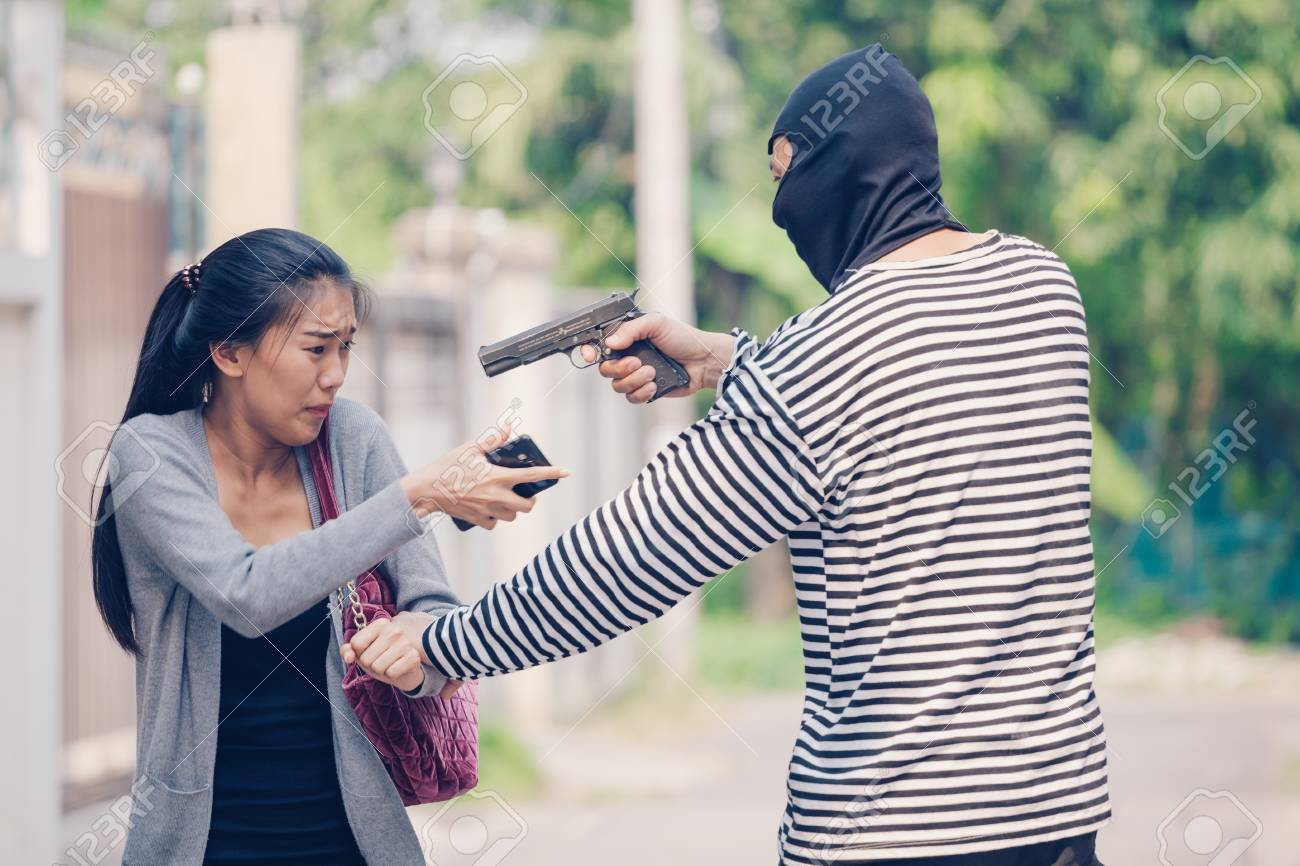

In [9]:
from google.colab import files
from PIL import Image
import io

uploaded_image = files.upload()

for filename in uploaded_image:
    image = Image.open(io.BytesIO(uploaded_image[filename]))
    print("Uploaded:", filename)
    print("Image size:", image.size)

    display(image)

In [10]:
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

if probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability) * 100

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2f}%")

Prediction: NORMAL
Confidence: 100.00%


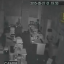

Prediction: ABNORMAL
Confidence: 99.62%


In [24]:
from PIL import Image

image_path = "/content/ucf_test/Burglary032_x264_6920.png"

image = Image.open(image_path).convert("RGB")

display(image)

image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

if probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability) * 100

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2f}%")

In [12]:
!pip install -q kaggle

In [13]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [14]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✅ Kaggle API configured!")

✅ Kaggle API configured!


In [15]:
!kaggle datasets list -s "UCF Crime Dataset"

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
odins0n/ucf-crime-dataset                                    UCF Crime Dataset                                  11827280807  2021-11-11 13:16:24.083000          42576        290  0.875            
vigneshwar472/ucaucf-crime-annotation-dataset                UCA(UCF Crime Annotation) Dataset                 103085257090  2024-09-18 09:30:54.267000          11104          9  1                
minhajuddinmeraj/anomalydetectiondatasetucf                  Anomaly-Detection-Dataset-UCF                      41022653087  2022-05-20 20:29:17.897000          23963         87  0.625            
minmints/ufc-cr

In [16]:
!kaggle datasets files odins0n/ucf-crime-dataset

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U6hvzVfGCBshGI1kV3fiT3wGcLJI8G8wtdriC_WX2Q0gOOcoqpdX7f4VLjJ175kwiWSuGAjg6VRGk6xZZ_yDBD_t0prQgmxzrk_DC3x0LBVY_sd0SAJPlefvflSQ2IHZukoAH84p9epPA
name                               size  creationDate                
---------------------------------  ----  --------------------------  
Test/Abuse/Abuse028_x264_0.png     6746  2021-11-11 13:19:19.368000  
Test/Abuse/Abuse028_x264_10.png    6925  2021-11-11 13:19:19.378000  
Test/Abuse/Abuse028_x264_100.png   7000  2021-11-11 13:19:19.368000  
Test/Abuse/Abuse028_x264_1000.png  6986  2021-11-11 13:19:19.368000  
Test/Abuse/Abuse028_x264_1010.png  6907  2021-11-11 13:19:19.346000  
Test/Abuse/Abuse028_x264_1020.png  6895  2021-11-11 13:19:19.378000  
Test/Abuse/Abuse028_x264_1030.png  6880  2021-11-11 13:19:19.357000  
Test/Abuse/Abuse028_x264_1040.png  6873  2021-11-11 13:19:19.400000  
Test/Abuse/Abuse028_x264_1050.png  6873  2021-11-11 13:19:19.410000  
Test/Abuse/Abuse028_x264_1060.png  6890  2021

In [19]:
!kaggle datasets download odins0n/ucf-crime-dataset -f "Test/Burglary/Burglary032_x264_6920.png" -p /content/ucf_test

Dataset URL: https://www.kaggle.com/datasets/odins0n/ucf-crime-dataset
License(s): CC0-1.0
100% 7.18k/7.18k [00:00<00:00, 19.1MB/s]



In [20]:
!mkdir -p /content/ucf_test

!kaggle datasets download \
  -d odins0n/ucf-crime-dataset \
  -f "Test/Burglary/Burglary032_x264_6920.png" \
  -p /content/ucf_test

Dataset URL: https://www.kaggle.com/datasets/odins0n/ucf-crime-dataset
License(s): CC0-1.0
Burglary032_x264_6920.png: Skipping, found more recently modified local copy (use --force to force download)


In [21]:
import os

print(os.listdir("/content/ucf_test"))

['Burglary032_x264_6920.png', 'ucf-crime-dataset.zip', 'Test']


Image size: (64, 64)


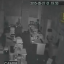

In [22]:
from PIL import Image

img = Image.open("/content/ucf_test/Burglary032_x264_6920.png")

print("Image size:", img.size)
display(img)

In [25]:
image_path = "/content/ucf_test/Burglary032_x264_6920.png"

result = predict_image(image_path)

print(result)

NameError: name 'predict_image' is not defined

In [26]:
!kaggle datasets download \
  -d odins0n/ucf-crime-dataset \
  -f "Test/NormalVideos/Normal_Videos_935_x264_57210.png" \
  -p /content/ucf_test

Dataset URL: https://www.kaggle.com/datasets/odins0n/ucf-crime-dataset
License(s): CC0-1.0
100% 7.64k/7.64k [00:00<00:00, 22.6MB/s]



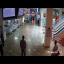

Prediction: NORMAL
Confidence: 98.09%


In [27]:
from PIL import Image

image_path = "/content/ucf_test/Normal_Videos_935_x264_57210.png"

image = Image.open(image_path).convert("RGB")

display(image)

image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

if probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability) * 100

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2f}%")

## Demo Results

The trained ResNet18 model was tested on two known UCF-Crime test frames.

### 1. Burglary Test Frame

- **Actual:** ABNORMAL (Burglary)
- **Prediction:** ABNORMAL
- **Confidence:** 99.62%

### 2. Normal Test Frame

- **Actual:** NORMAL
- **Prediction:** NORMAL
- **Confidence:** 98.09%

> These examples demonstrate the inference pipeline. Overall performance is reported using the 4,000-image test set.